In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive (11).zip to archive (11) (1).zip


In [3]:
!unzip -q 'archive (11).zip'

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.6798 - loss: 0.6344 - val_accuracy: 0.7200 - val_loss: 0.5458
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8227 - loss: 0.4533 - val_accuracy: 0.7200 - val_loss: 0.5485
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.8227 - loss: 0.3885 - val_accuracy: 0.7200 - val_loss: 0.4857
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 4s/step - accuracy: 0.8818 - loss: 0.3127 - val_accuracy: 0.8000 - val_loss: 0.5021
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9064 - loss: 0.2299 - val_accuracy: 0.8400 - val_loss: 0.4383
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.9557 - loss: 0.1373 - val_accuracy: 0.8200 - val_loss: 0.5964
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.9754 - loss: 0.0670 - val_accuracy: 0.8000 - val_loss: 0.6622
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.9951 - loss: 0.0297 - val_accuracy: 0.8600 - val_loss: 0.6361
Epoch 9/

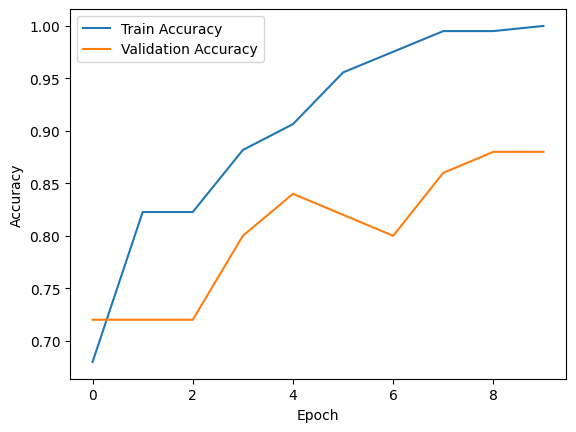

In [4]:
# Brain Tumor Detection CNN (Google Colab)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

# parameters
img_size = 224
batch_size = 32

# dataset path after unzip
dataset_path = "/content/brain_tumor_dataset"

# data preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# training data
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# validation data
val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# CNN model
model = models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128,activation='relu'))

model.add(layers.Dense(2,activation='softmax'))

# compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# summary
model.summary()

# train model
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

# evaluate
loss, accuracy = model.evaluate(val_generator)

print("Validation Accuracy:", accuracy)

# plot accuracy graph
plt.plot(history.history['accuracy'],label="Train Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()